# 06. Demand Forecasting using Prophet

## Objective

The objective of this notebook is to forecast future daily sales revenue using Facebook Prophet, a time series forecasting model.

This notebook performs:
- Loading the feature engineered retail dataset
- Preparing daily sales time series
- Training a Prophet forecasting model
- Forecasting future sales
- Evaluating forecasting performance
- Saving forecast results for the Streamlit dashboard

### Input
- online_retail_II_feature_engineered.csv

### Output
- daily_sales.csv
- forecast.csv
- prophet_model.pkl

## 1. Import Libraries

In [12]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Forecasting
from prophet import Prophet

# Model saving
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## 2. Load Feature Engineered Dataset

In [13]:
# Load feature engineered dataset
df = pd.read_csv("../data/processed/online_retail_II_feature_engineered.csv")

print("Dataset loaded successfully!")

print("\nDataset Shape:")
print(df.shape)

print("\nFirst Five Rows:")
display(df.head())

Dataset loaded successfully!

Dataset Shape:
(779425, 20)

First Five Rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Year,Month,MonthName,Quarter,Day,DayOfWeek,Hour,Revenue,TimeOfDay,Season,BasketSize,UniqueProducts
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009,12,December,4,1,Tuesday,7,83.4,Morning,Winter,166,8
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,December,4,1,Tuesday,7,81.0,Morning,Winter,166,8
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,December,4,1,Tuesday,7,81.0,Morning,Winter,166,8
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009,12,December,4,1,Tuesday,7,100.8,Morning,Winter,166,8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009,12,December,4,1,Tuesday,7,30.0,Morning,Winter,166,8


## 3. Data Validation

In [16]:
print("=" * 60)
print("Dataset Information")
print("=" * 60)
df.info()

print("\nDataset Shape:", df.shape)

print("\nMissing Values:", df.isnull().sum().sum())

print("Duplicate Rows:", df.duplicated().sum())

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 779425 entries, 0 to 779424
Data columns (total 20 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Invoice         779425 non-null  int64  
 1   StockCode       779425 non-null  str    
 2   Description     779425 non-null  str    
 3   Quantity        779425 non-null  int64  
 4   InvoiceDate     779425 non-null  str    
 5   Price           779425 non-null  float64
 6   Customer ID     779425 non-null  float64
 7   Country         779425 non-null  str    
 8   Year            779425 non-null  int64  
 9   Month           779425 non-null  int64  
 10  MonthName       779425 non-null  str    
 11  Quarter         779425 non-null  int64  
 12  Day             779425 non-null  int64  
 13  DayOfWeek       779425 non-null  str    
 14  Hour            779425 non-null  int64  
 15  Revenue         779425 non-null  float64
 16  TimeOfDay       779425 non-null  str    
 17  S

In [17]:
# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Aggregate total daily revenue
daily_sales = (
    df.groupby(df["InvoiceDate"].dt.date)["Revenue"]
      .sum()
      .reset_index()
)

# Rename columns for Prophet
daily_sales.columns = ["ds", "y"]

# Convert ds back to datetime
daily_sales["ds"] = pd.to_datetime(daily_sales["ds"])

print("Daily sales dataset created successfully!")

print("Shape:", daily_sales.shape)

display(daily_sales.head())

Daily sales dataset created successfully!
Shape: (604, 2)


,ds,y
0,2009-12-01,43894.87
1,2009-12-02,52762.06
2,2009-12-03,67413.62
3,2009-12-04,33913.81
4,2009-12-05,9803.05


In [18]:
daily_sales.to_csv(
    "../data/processed/daily_sales.csv",
    index=False
)

print("daily_sales.csv saved successfully!")

daily_sales.csv saved successfully!


## 7. Train Prophet Forecasting Model

In [19]:
from prophet import Prophet

# Initialize Prophet model
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

# Train the model
prophet_model.fit(daily_sales)

print("✅ Prophet model trained successfully!")

00:31:19 - cmdstanpy - INFO - Chain [1] start processing
00:31:20 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet model trained successfully!


## 8. Generate Future Sales Forecast

In [20]:
# Create future dataframe for the next 90 days
future = prophet_model.make_future_dataframe(periods=90)

# Generate forecast
forecast = prophet_model.predict(future)

print("Forecast generated successfully!")

print("\nForecast Shape:")
print(forecast.shape)

forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail()

Forecast generated successfully!

Forecast Shape:
(694, 19)


,ds,yhat,yhat_lower,yhat_upper
689,2012-03-04,16856.891153,1639.667981,32563.900691
690,2012-03-05,28124.838766,14105.205974,43513.839733
691,2012-03-06,30456.694639,15089.850187,45692.697784
692,2012-03-07,27303.473909,12910.593807,42868.392004
693,2012-03-08,34325.988430,17630.272362,48663.495267


## 9. Forecast Visualization

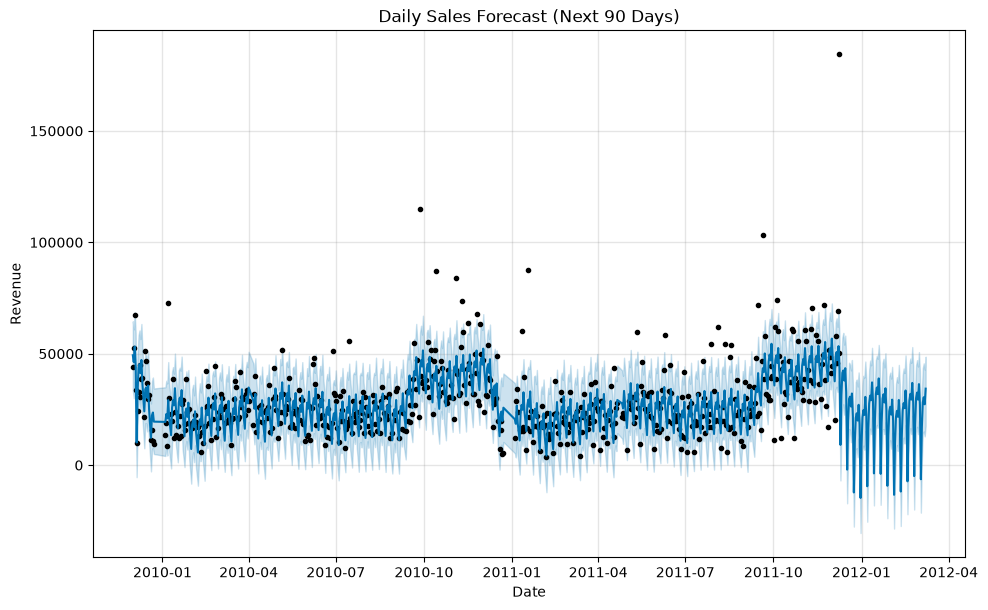

In [21]:
# Plot forecast
fig1 = prophet_model.plot(forecast)

plt.title("Daily Sales Forecast (Next 90 Days)")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.show()

## 10. Forecast Components

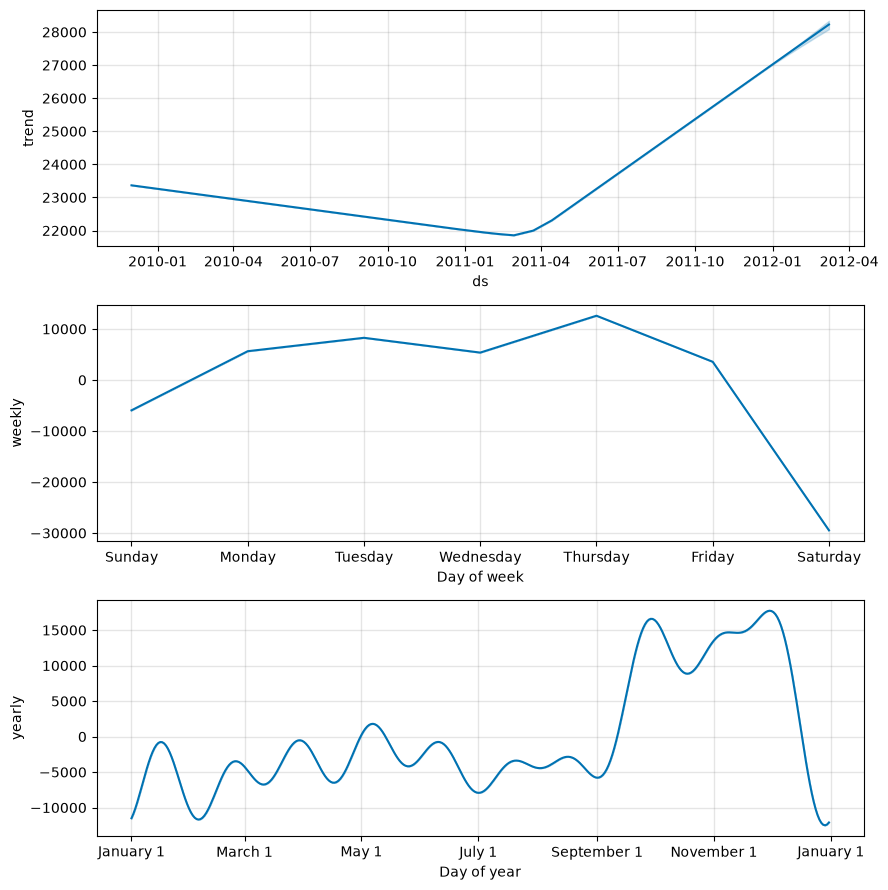

In [22]:
# Plot trend and seasonality
fig2 = prophet_model.plot_components(forecast)

plt.show()

## 11. Model Evaluation

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Compare actual and predicted values on historical data
actual = daily_sales["y"].values
predicted = forecast["yhat"][:len(daily_sales)].values

# Evaluation metrics
mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))

print("Model Evaluation")
print("-" * 30)
print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")

Model Evaluation
------------------------------
Mean Absolute Error (MAE): 7,843.07
Root Mean Squared Error (RMSE): 12,039.62


## 12. Save Forecast Results

In [24]:
# Save complete forecast
forecast.to_csv(
    "../data/processed/forecast.csv",
    index=False
)

print("forecast.csv saved successfully!")

forecast.csv saved successfully!


In [25]:
# Save trained Prophet model
joblib.dump(
    prophet_model,
    "../models/prophet_model.pkl"
)

print("prophet_model.pkl saved successfully!")

prophet_model.pkl saved successfully!


## 13. Business Insights

### Key Findings

- Daily sales were successfully aggregated and forecasted using the Prophet time-series model.
- The model captured both the overall sales trend and weekly seasonality.
- Weekly patterns indicate that sales vary significantly across different days of the week.
- The generated 90-day forecast can support inventory planning, demand forecasting, and business decision-making.
- Forecast outputs will be used in the Streamlit dashboard to visualize future sales trends.